# Dogs & Cats com Vision Transformer (ViT) 🐶🐱

Este projeto objetiva implementar um classificador de Cães e Gatos, usando um modelo pré-treinado do tipo transformer de visão, com PyTorch da biblioteca Hugging Face Transformers.

### ⭐ Destaques do Projeto:
*   **Modelo:** Vision Transformer (ViT) pré-treinado da Google via Hugging Face.
*   **Framework:** PyTorch para treinamento e inferência.
*   **Dataset:** Amostra balanceada contendo:
    *   **Treino:** 1.002 imagens (501 dogs; 501 cats).
    *   **Teste:** 200 imagens (100 dogs; 100 cats).
*   **Objetivo:** Demonstrar o poder do *transfer learning* em arquiteturas baseadas em Atenção para imagens.

## 1. Preparação dos dados 📦

In [ ]:
# Instalar pacotes necessários
!pip install -q transformers datasets evaluate

In [ ]:
# Baixar os datasets (treino) do GitHub
!wget https://raw.githubusercontent.com/scadriano/lia1_2026_1/main/Aula%2010%20-%20Modelo%20para%20Identificar%20Cats%20or%20Dogs/dataset_treino.zip

--2026-04-01 13:06:37--  https://raw.githubusercontent.com/scadriano/lia1_2026_1/main/Aula%2010%20-%20Modelo%20para%20Identificar%20Cats%20or%20Dogs/dataset_treino.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22990940 (22M) [application/zip]
Saving to: ‘dataset_treino.zip.2’

dataset_treino.zip. 100%[===================>]  21.93M  --.-KB/s    in 0.1s    

2026-04-01 13:06:38 (211 MB/s) - ‘dataset_treino.zip.2’ saved [22990940/22990940]



In [ ]:
# Baixar os datasets (teste) do GitHub
!wget https://raw.githubusercontent.com/scadriano/lia1_2026_1/main/Aula%2010%20-%20Modelo%20para%20Identificar%20Cats%20or%20Dogs/dataset_teste.zip

--2026-04-01 13:06:38--  https://raw.githubusercontent.com/scadriano/lia1_2026_1/main/Aula%2010%20-%20Modelo%20para%20Identificar%20Cats%20or%20Dogs/dataset_teste.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4536691 (4.3M) [application/zip]
Saving to: ‘dataset_teste.zip.2’

dataset_teste.zip.2 100%[===================>]   4.33M  --.-KB/s    in 0.05s   

2026-04-01 13:06:38 (78.7 MB/s) - ‘dataset_teste.zip.2’ saved [4536691/4536691]



In [ ]:
# Descompactar os arquivos (treino) silenciosamente
!unzip -oq dataset_treino.zip

In [ ]:
# Descompactar os arquivos (teste) silenciosamente
!unzip -oq dataset_teste.zip

In [ ]:
# Listar conteúdo básico para conferência (apenas os primeiros itens)
print("--- Conteúdo do diretório atual ---")
!ls -d */

print("\n--- Amostra do Dataset de Treino ---")
!ls dataset_treino | head -n 5

print("\n--- Amostra do Dataset de Teste ---")
!ls dataset_teste | head -n 5

--- Conteúdo do diretório atual ---
dataset_teste/	dataset_treino/  sample_data/

--- Amostra do Dataset de Treino ---
cats
dogs

--- Amostra do Dataset de Teste ---
100.jpg
101.jpg
102.jpg
103.jpg
104.jpg


✅ Verificando amostras do dataset de treino:


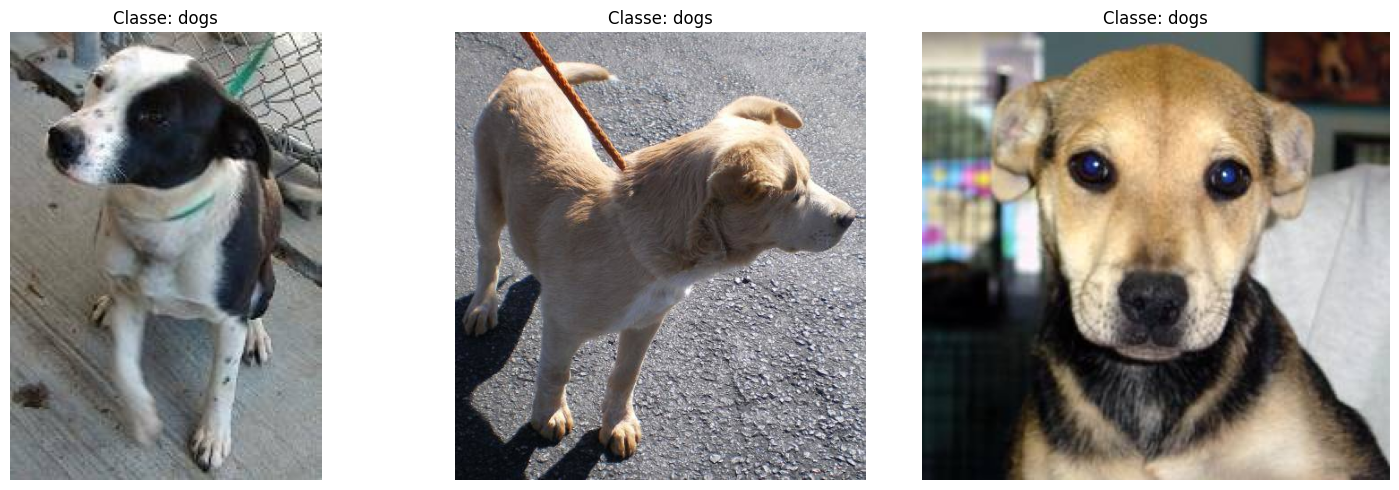

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

def visualizar_amostras(base_path, num_images=3):
    classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i in range(num_images):
        chosen_class = random.choice(classes)
        class_path = os.path.join(base_path, chosen_class)
        image_name = random.choice(os.listdir(class_path))
        image_path = os.path.join(class_path, image_name)

        img = Image.open(image_path)
        axes[i].imshow(img)
        axes[i].set_title(f"Classe: {chosen_class}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("✅ Verificando amostras do dataset de treino:")
visualizar_amostras('./dataset_treino')


In [ ]:
# Importação de bibliotecas
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets import ImageFolder
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Definir dispositivo (GPU se disponível)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Usando dispositivo: {device}')

✅ Usando dispositivo: cuda


In [ ]:
# Nome do modelo pré-treinado
model_name = "google/vit-base-patch16-224"

# Carregar processador e modelo
processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=2,                 # 2 classes: gato ou cachorro
    ignore_mismatched_sizes=True  # permite ajustar camadas finais
)
model = model.to(device)

In [ ]:
# Criar o dataset personalizado
class DogsAndCatsDataset(Dataset):
    def __init__(self, root_dir, processor):
        self.dataset = ImageFolder(root_dir)
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        # Pré-processar imagem para o ViT
        inputs = self.processor(images=image, return_tensors="pt")
        pixel_values = inputs['pixel_values'].squeeze()
        return pixel_values, label

In [ ]:
# Dividir o dataset em treino e validação
import torch
from collections import Counter

# Diretório de treino
train_dir = './dataset_treino'

# Criar dataset completo
full_dataset = DogsAndCatsDataset(train_dir, processor)

# Dividir em treino (80%) e validação (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Fixar semente para divisão reproduzível
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

print(f'Total de imagens: {len(full_dataset)}')
print(f'Treinamento: {len(train_dataset)} | Validação: {len(val_dataset)}')

# Descobrir nomes das classes
class_names = full_dataset.dataset.classes
print("Classes encontradas:", class_names)

# Contar quantas imagens de cada classe foram para treino e validação
targets = full_dataset.dataset.targets

train_labels = [targets[i] for i in train_dataset.indices]
val_labels = [targets[i] for i in val_dataset.indices]

train_counts = Counter(train_labels)
val_counts = Counter(val_labels)

print("\nDistribuição no treino:")
for class_idx, class_name in enumerate(class_names):
    print(f" - {class_name}: {train_counts[class_idx]} imagens")

print("\nDistribuição na validação:")
for class_idx, class_name in enumerate(class_names):
    print(f" - {class_name}: {val_counts[class_idx]} imagens")

# DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

Total de imagens: 1002
Treinamento: 801 | Validação: 201
Classes encontradas: ['cats', 'dogs']

Distribuição no treino:
 - cats: 400 imagens
 - dogs: 401 imagens

Distribuição na validação:
 - cats: 101 imagens
 - dogs: 100 imagens


## 2. Treinamento do Modelo ⚙️

In [ ]:
# Treinamento

# Configurações de treino
num_epochs = 10
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

# Loop de treinamento
for epoch in range(num_epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}')
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values=images, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix(
            loss=total_loss/(len(progress_bar)),
            accuracy=100.*correct/total
        )

    # Validação
    model.eval()
    val_correct, val_total, val_loss = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(pixel_values=images, labels=labels)
            val_loss += outputs.loss.item()
            _, predicted = outputs.logits.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    print(f"📊 Epoch {epoch+1}/{num_epochs}")
    print(f"  Treino: Loss {total_loss/len(train_loader):.4f} | Acc {100.*correct/total:.2f}%")
    print(f"  Val   : Loss {val_loss/len(val_loader):.4f} | Acc {100.*val_correct/val_total:.2f}%\n")


Epoch 1/10: 100%|██████████| 26/26 [00:35<00:00,  1.38s/it, accuracy=93.1, loss=0.173]


📊 Epoch 1/10
  Treino: Loss 0.1731 | Acc 93.13%
  Val   : Loss 0.0066 | Acc 100.00%



Epoch 2/10: 100%|██████████| 26/26 [00:35<00:00,  1.37s/it, accuracy=99.9, loss=0.00534]


📊 Epoch 2/10
  Treino: Loss 0.0053 | Acc 99.88%
  Val   : Loss 0.0022 | Acc 100.00%



Epoch 3/10: 100%|██████████| 26/26 [00:34<00:00,  1.31s/it, accuracy=100, loss=0.00159]


...

📊 Epoch 8/10
  Treino: Loss 0.0004 | Acc 100.00%
  Val   : Loss 0.0005 | Acc 100.00%



Epoch 9/10: 100%|██████████| 26/26 [00:34<00:00,  1.33s/it, accuracy=100, loss=0.000305]


📊 Epoch 9/10
  Treino: Loss 0.0003 | Acc 100.00%
  Val   : Loss 0.0004 | Acc 100.00%



Epoch 10/10: 100%|██████████| 26/26 [00:34<00:00,  1.32s/it, accuracy=100, loss=0.000248]


📊 Epoch 10/10
  Treino: Loss 0.0002 | Acc 100.00%
  Val   : Loss 0.0003 | Acc 100.00%



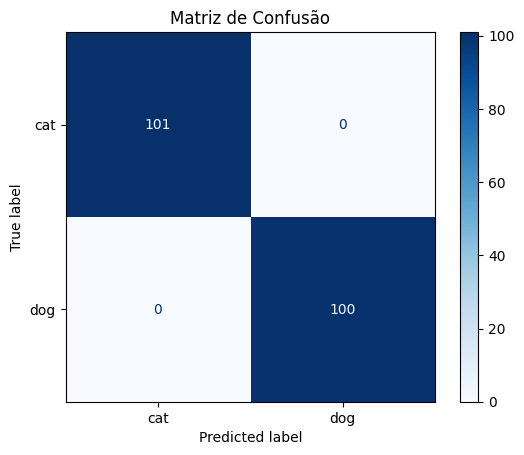

In [ ]:
# Gerar a Matriz de Confusão
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(pixel_values=images, labels=labels)
        _, predicted = outputs.logits.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Matriz de confusão (0 cat; 1 dog)
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['cat','dog'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão")
plt.show()

## 3. Deploy e Inferência 🚀

🐾 Classe predita: Gato | Confiança: 99.96%


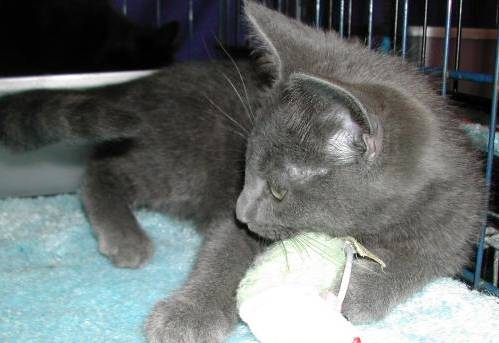

In [ ]:
from PIL import Image

# Carregar imagem de teste
test_image_path = './dataset_teste/100.jpg'
image = Image.open(test_image_path)

# Pré-processar
inputs = processor(images=image, return_tensors="pt").to(device)

# Inferência
model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(probabilities, dim=-1).item()

# Mapeamento para português
traducao = {'cats': 'Gato', 'dogs': 'Cachorro'}

class_names = full_dataset.dataset.classes
label_original = class_names[predicted_class]
predicted_label = traducao.get(label_original, label_original)
confidence = probabilities[0][predicted_class].item()

print(f"🐾 Classe predita: {predicted_label} | Confiança: {confidence:.2%}")
image

### 3.1. Teste com Imagem Local 📷

Saving duno.jpg to duno (2).jpg
📷 Imagem enviada: duno (2).jpg
🐾 Classe predita: Cachorro | Confiança: 99.97%


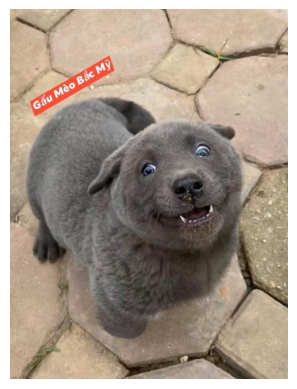

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Fazer upload de uma imagem do computador
uploaded = files.upload()

# Pegar o nome do arquivo enviado
test_image_path = list(uploaded.keys())[0]

# Abrir imagem
image = Image.open(test_image_path).convert("RGB")

# Pré-processar
inputs = processor(images=image, return_tensors="pt").to(device)

# Inferência
model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(probabilities, dim=-1).item()

# Mapeamento para português
traducao = {'cats': 'Gato', 'dogs': 'Cachorro'}

# Nomes reais das classes
class_names = full_dataset.dataset.classes
label_original = class_names[predicted_class]
predicted_label = traducao.get(label_original, label_original)
confidence = probabilities[0][predicted_class].item()

print(f"📷 Imagem enviada: {test_image_path}")
print(f"🐾 Classe predita: {predicted_label} | Confiança: {confidence:.2%}")

plt.imshow(image)
plt.axis("off")
plt.show()